In [26]:
import numpy as np
import pandas as pd

In [27]:
def euclidean_distance(X,Y):        
    if len(X)-1!=len(Y):
        raise ValueError('Check the completeness of data')
    else:
        distance_sum = 0 
        # ignoring the last element, since that is the class
        for i in range(len(X)-1):
            distance_sum += (X[i] - Y[i])**2
        return np.sqrt(distance_sum).round(2)

In [28]:
# p1, p2, p3, class
data = [
    [1,1,1,0],
    [1,2,1,0],
    [2,1,2,0],
    [2,2,1,0],
    [6,6,6,1],
    [6,7,6,1],
    [7,6,7,1],
    [7,7,6,1]
]

In [29]:
def knn_classifier(training_data,observation,K=1):
    
    if len(observation) == 0 or len(observation) != len(training_data[0]) - 1:
        raise ValueError('Check the observation data')

    # array of tuple with data and distance
    nearest_neighbours = []
        
    for training_data_iter in training_data:
        distance = euclidean_distance(training_data_iter, observation)
        
        nearest_neighbours.append({"data":training_data_iter, "distance":distance})
        
        # if the array length exceeds K, remove the largest distance entry
        if len(nearest_neighbours) > K:
            max_distance_entry = max(nearest_neighbours, key=lambda x: x['distance'])
            nearest_neighbours.remove(max_distance_entry)
    
    # print(nearest_neighbours)
    
    counts = {}

    for item in nearest_neighbours:
        cls = item["data"][-1]   
        counts[cls] = counts.get(cls, 0) + 1
        
    most_common_class = max(counts, key=counts.get)
    return most_common_class


def predict_K3(observation):
    K = 3    
    print(str(observation) + " belongs to class " + str(knn_classifier(data,observation,K)))    

In [30]:
observation = [5,6,6]
predict_K3(observation)

[5, 6, 6] belongs to class 1


In [31]:
# modifying to work with pd dataframe, with clear separation of predictors and class

In [32]:
def euclidean_distance_v2(X,Y):            
    if len(X)!=len(Y):
        raise ValueError('Check the completeness of data')
    else:
        distance_sum = 0 
        # ignoring the last element, since that is the class
        for i in range(len(X)):
            distance_sum += (X[i] - Y[i])**2
        return np.sqrt(distance_sum).round(2)

In [33]:
n = 1000
x1 = np.linspace(1, 100, n)
x2 = x1 * 1.5
x3 = x1 * 2
y  = np.concatenate([np.zeros(n//2), np.ones(n//2)])
df = pd.DataFrame({'x1':x1,'x2':x2,'x3':x3,'y': y.astype(int)})
df.describe()

,x1,x2,x3,y
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,50.500000,75.750000,101.000000,0.50000
std,28.621746,42.932619,57.243492,0.50025
min,1.000000,1.500000,2.000000,0.00000
25%,25.750000,38.625000,51.500000,0.00000
50%,50.500000,75.750000,101.000000,0.50000
75%,75.250000,112.875000,150.500000,1.00000
max,100.000000,150.000000,200.000000,1.00000


In [34]:
def find_nearest_neighbours(data_point,nearest_neighbours,observation,K):
    distance = euclidean_distance_v2(data_point.values[:-1], observation)
    class_value = data_point.values[-1]
    # store just the class value and distance, instead of 
    nearest_neighbours.append({"class":class_value, "distance":distance})
        
    # if the array length exceeds K, remove the largest distance entry
    if len(nearest_neighbours) > K:
        max_index = max(range(len(nearest_neighbours)), 
                        key=lambda i: nearest_neighbours[i]['distance'])
        nearest_neighbours.pop(max_index)
    return nearest_neighbours    

# store class's count in a dictionary. and its min distance in another dictionary
# further handle the tie by choosing the neighbouring class with minimum distance
def predict_class(nearest_neighbours):
    counts = {}
    class_min_distance = {}
    for item in nearest_neighbours:
        cls = item["class"]
        counts[cls] = counts.get(cls, 0) + 1
        if cls not in class_min_distance or item["distance"] < class_min_distance[cls]:
            class_min_distance[cls] = item["distance"]
    
    max_count = max(counts.values())
    tied_classes = [cls for cls, count in counts.items() if count == max_count]
    return min(tied_classes, key=lambda cls: class_min_distance[cls]).astype(int)
    
def knn_classifier_v2(training_data,observation,K=1):
    
    if len(observation) == 0 or len(observation) != len(training_data.iloc[0]) - 1:
        raise ValueError('Check the observation data')

    # array of tuple with data and distance
    nearest_neighbours = []

    # used apply method, which is faster than iterrows
    train_data.apply(find_nearest_neighbours, axis = 1, args=(nearest_neighbours, observation, K))
    
    return predict_class(nearest_neighbours)    

In [35]:
def predict_K3_v2(observation):
    K = 3    
    print(str(observation) + " belongs to class " + str(knn_classifier_v2(df,observation,K)))
    
observation = [100,100,100]
predict_K3_v2(observation)

[100, 100, 100] belongs to class 1


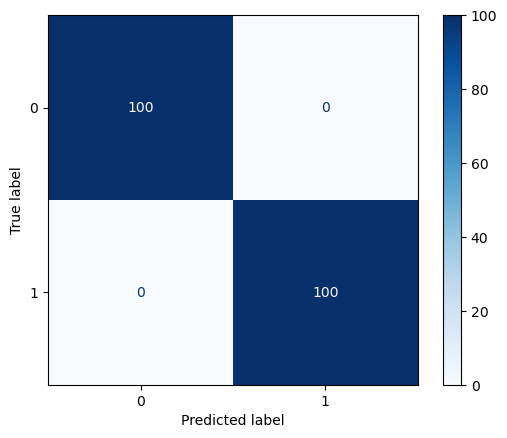


Accuracy: 1.0


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = df[['x1','x2','x3']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_data = X_train.copy()
train_data['y'] = y_train

y_pred = []

for _, row in X_test.iterrows():
    pred = knn_classifier_v2(train_data, row.tolist(), 3)
    y_pred.append(pred)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

accuracy = sum(y_test.values == y_pred) / len(y_test)
print("\nAccuracy:", accuracy)

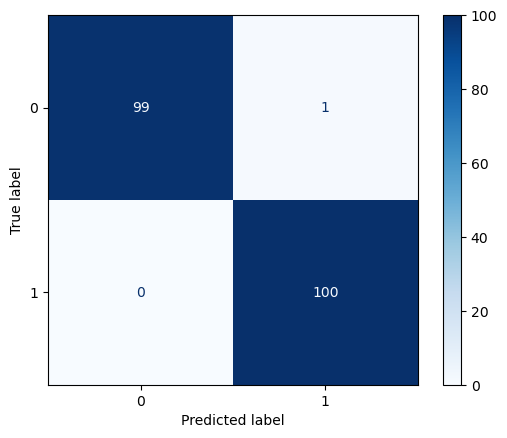


Accuracy: 0.995


In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

print("\nAccuracy:", knn.score(X_test, y_test))

In [42]:
# use make_classification to generate data
from sklearn.datasets import make_classification
import pandas as pd

X, y = make_classification(
    n_samples=1000,
    n_features=3,
    n_informative=2,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=0.8,     # smaller = more overlap
    flip_y=0.1,        # label noise
    random_state=42
)

df = pd.DataFrame(X, columns=['x1','x2','x3'])
df['y'] = y

print(df.head())

         x1        x2        x3  y
0  0.859565  0.749748 -0.868293  1
1  1.624965 -0.061045  0.570613  1
2 -2.125695 -0.901824 -0.229549  2
3 -1.015384  0.540712  0.668742  0
4  0.404540 -1.027009  0.352505  2


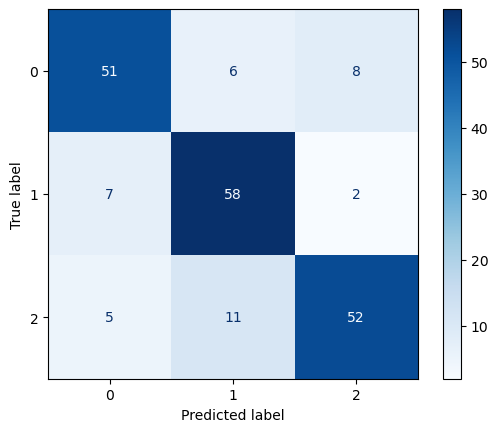


Accuracy: 0.805


In [43]:
X = df[['x1','x2','x3']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_data = X_train.copy()
train_data['y'] = y_train

y_pred = []

for _, row in X_test.iterrows():
    pred = knn_classifier_v2(train_data, row.tolist(), 3)
    y_pred.append(pred)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

accuracy = sum(y_test.values == y_pred) / len(y_test)
print("\nAccuracy:", accuracy)

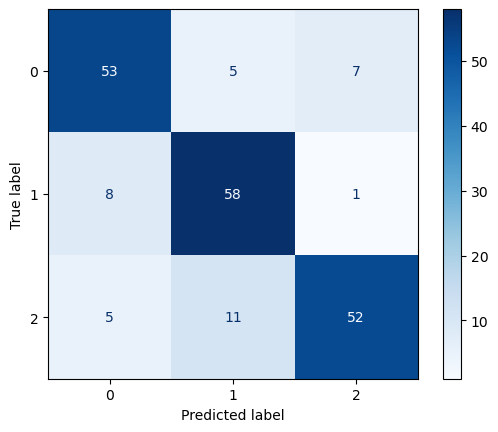


Accuracy: 0.815


In [44]:
knn = KNeighborsClassifier(n_neighbors=3, metric="euclidean")

knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

print("\nAccuracy:", knn.score(X_test, y_test))